In [1]:
#=================================================
# 1. IMPORT LIBRARIES
#==================================================

import numpy as np
import pandas as pd
import os
import joblib

!Pip install shap
import shap
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier


In [2]:
# ==============
# 2.LOAD DATASET
# ===============

df = pd.read_csv('ObesityDataSet.csv')

In [3]:
# ================
# 3. BASIC EDA
# ================

print('shape:',df.shape)

print("Basic infomation:",df.info())

df.head()



shape: (2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF             

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
print('NOBEYESDAD VALUE COUNT:')
print(df['NObeyesdad'].value_counts())

NOBEYESDAD VALUE COUNT:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [5]:
df.describe(include = 'all')

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


In [6]:
#checking for missing value
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [7]:
# =========================================
# 4. FEATURE ENGINEERING (BMI)
# =========================================
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [8]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad', 'BMI'],
      dtype='object')

In [9]:
# ==================
# 5. visualization
# ==================

In [10]:
# Set up visual styling
sns.set(style="whitegrid")


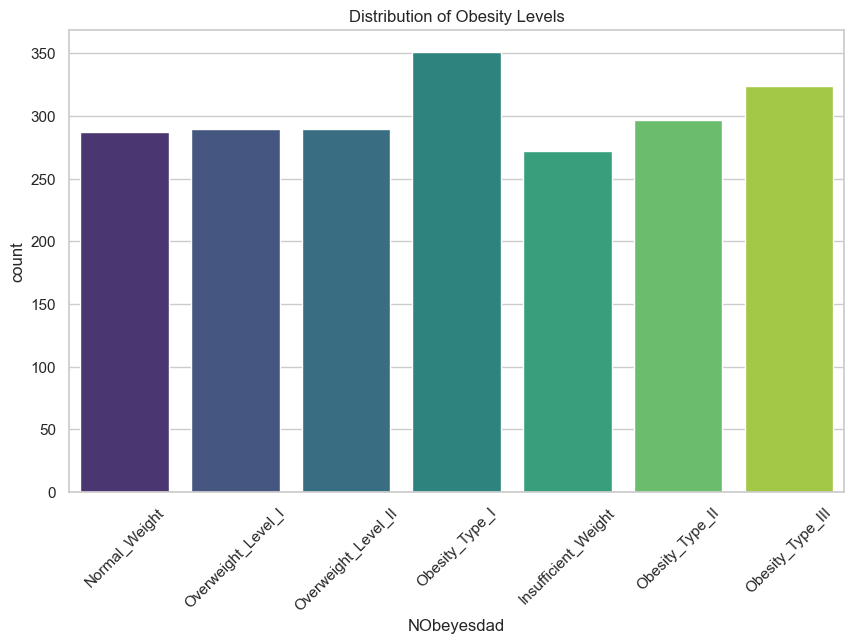

In [11]:
# Plot distribution of the target variable (NObeyesdad)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='NObeyesdad',hue ='NObeyesdad', legend=False, palette="viridis")
plt.title("Distribution of Obesity Levels")
plt.xticks(rotation=45)
plt.show()

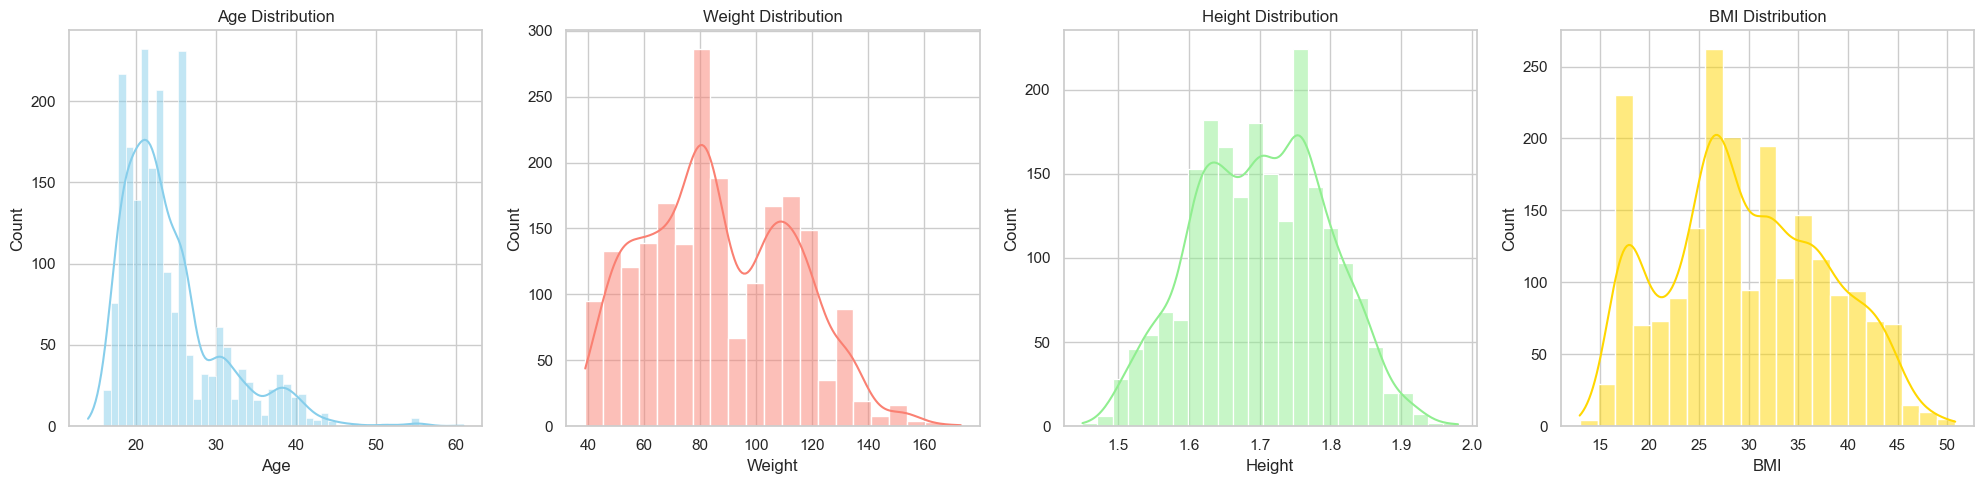

In [12]:
# Plot distribution of Age, Weight, and Height
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.histplot(data=df, x="Age", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Age Distribution")

sns.histplot(data=df, x="Weight", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Weight Distribution")

sns.histplot(data=df, x="Height", kde=True, ax=axes[2], color="lightgreen")
axes[2].set_title("Height Distribution")

sns.histplot(data=df, x="BMI", kde=True, ax=axes[3], color="gold")
axes[3].set_title("BMI Distribution")

plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_15764\1351919423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Gender", ax=axes[0], palette="pastel")
C:\Users\hp\AppData\Local\Temp\ipykernel_15764\1351919423.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="SMOKE", ax=axes[1], palette="pastel")
C:\Users\hp\AppData\Local\Temp\ipykernel_15764\1351919423.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="family_history_with_overweight", ax=axes[2], palette="pastel")


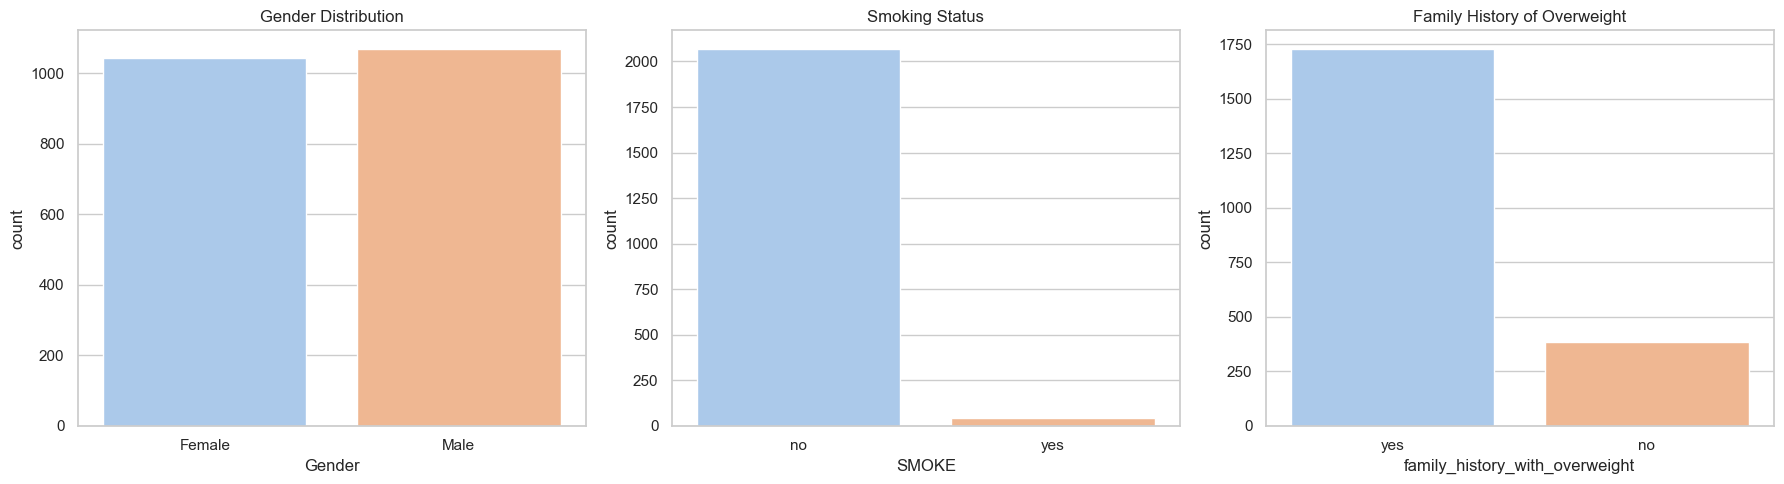

In [13]:
# Bar plot for categorical features like Gender, SMOKE, and family history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="Gender", ax=axes[0], palette="pastel")
axes[0].set_title("Gender Distribution")

sns.countplot(data=df, x="SMOKE", ax=axes[1], palette="pastel")
axes[1].set_title("Smoking Status")

sns.countplot(data=df, x="family_history_with_overweight", ax=axes[2], palette="pastel")
axes[2].set_title("Family History of Overweight")

plt.tight_layout()
plt.show()

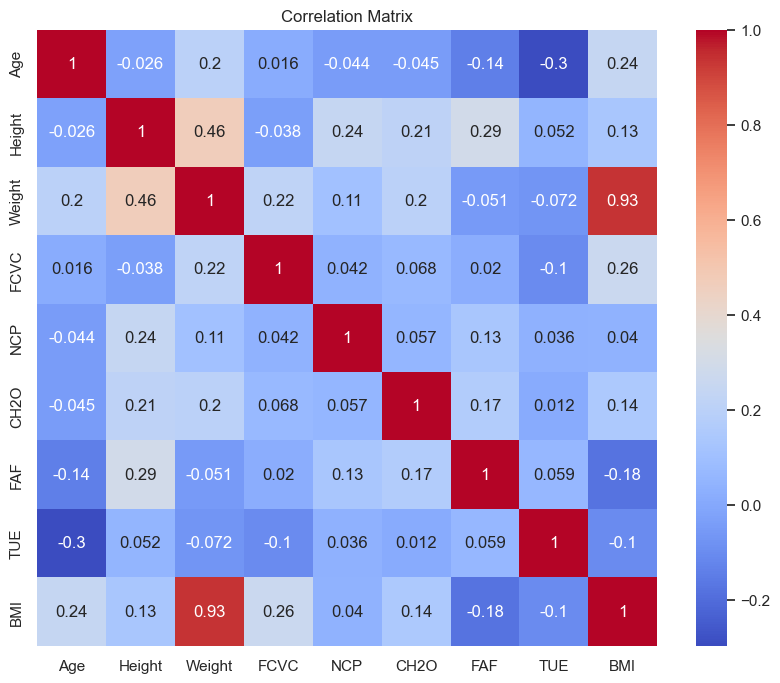

In [14]:
# Correlation Heatmap (pairplot)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [15]:

# =========================================
# 6. TARGET ENCODING (REQUIRED FOR XGB)
# =========================================

le = LabelEncoder()
df['NObeyesdad'] = le.fit_transform(df['NObeyesdad'])

In [16]:

# =========================================
# 7. DEFINE FEATURE SETS
# =========================================

# Base categorical columns
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC',
                    'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

# Numerical setups
num_base = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
num_bmi_only = ['Age', 'BMI', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
num_combined = ['Age', 'Height', 'Weight', 'BMI', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


In [17]:

# Target
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']


In [18]:
# =========================================
# 8. TRAIN / TEST SPLIT (FIRST)
# =========================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [19]:
# =========================================
# 9. FUNCTION: BUILD PIPELINE
# =========================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_combined),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)


In [20]:
# =========================================
# 10. DEFINE MODELS (LIGHT vs STRONG)
# =========================================
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, n_jobs=None))
])

xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    ))
])

In [21]:
# =========================================
# 11. CROSS-VALIDATION SETUP
# =========================================
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_weighted'
}

def eval_cv(pipe, name):
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        'Model': name,
        'CV_Accuracy': scores['test_accuracy'].mean(),
        'CV_F1': scores['test_f1'].mean()
    }

lr_cv = eval_cv(lr_pipe, "Logistic Regression")
xgb_cv = eval_cv(xgb_pipe, "XGBoost")

import pandas as pd
cv_results = pd.DataFrame([lr_cv, xgb_cv]).round(4)
print(cv_results)


                 Model  CV_Accuracy   CV_F1
0  Logistic Regression       0.9088  0.9079
1              XGBoost       0.9775  0.9775


In [22]:
# =========================================
# 12. SELECT BEST MODEL (BASED ON CV)
# =========================================
best_name = cv_results.sort_values('CV_F1', ascending=False).iloc[0]['Model']
print("Selected model:", best_name)

best_pipe = xgb_pipe if best_name == "XGBoost" else lr_pipe


Selected model: XGBoost


In [23]:
final_model = best_pipe
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'BMI', 'FCVC', 'NCP', 'CH2O',
                                                   'FAF', 'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model',
                 XGBClassifier(base_score=None, booster...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [24]:

# =========================================
# 13. FINAL EVALUATION (TEST SET ONCE)
# =========================================
from sklearn.metrics import classification_report, confusion_matrix

y_pred = final_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       0.98      0.95      0.96        58
           2       0.99      1.00      0.99        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.95      0.97      0.96        58
           6       0.98      0.97      0.97        58

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423


Confusion Matrix:

[[54  0  0  0  0  0  0]
 [ 1 55  0  0  0  2  0]
 [ 0  0 70  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  1  0  0  0 56  1]
 [ 0  0  1  0  0  1 56]]


In [25]:
#=====================
# 14. Best Features
#=====================

# Extract model + preprocessor
model = final_model.named_steps['model']
preprocessor = final_model.named_steps['preprocessor']

# Get categorical feature names
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(categorical_cols)

# Combine with numerical features
feature_names = num_combined + list(cat_features)

In [26]:
#feature importance (Tree Based)

import pandas as pd

importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                               Feature  Importance
3                                  BMI    0.406917
9                          Gender_Male    0.348582
16                             SCC_yes    0.069409
13                      CAEC_Sometimes    0.027057
2                               Weight    0.017240
5                                  NCP    0.015251
0                                  Age    0.014211
18                      CALC_Sometimes    0.014204
10  family_history_with_overweight_yes    0.011067
1                               Height    0.010854


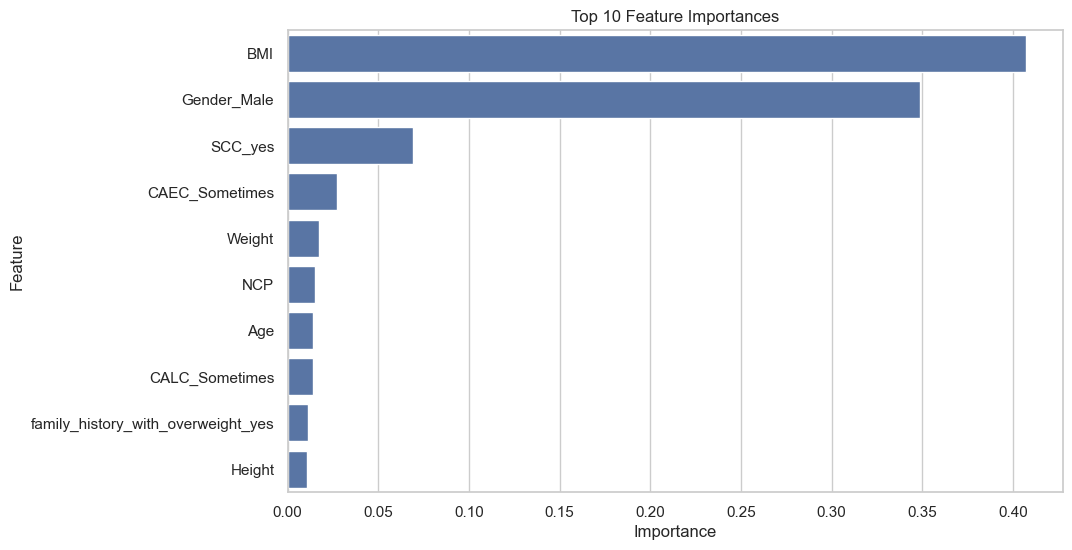

In [27]:
# Visualize Top features

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances")
plt.show()

In [28]:
#============================================
# 15. SHAP : How features affects prediction
#=============================================

# Extract transformed data
X_test_transformed = preprocessor.transform(X_test)

In [29]:
# Build SHAP explainer
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test_transformed)

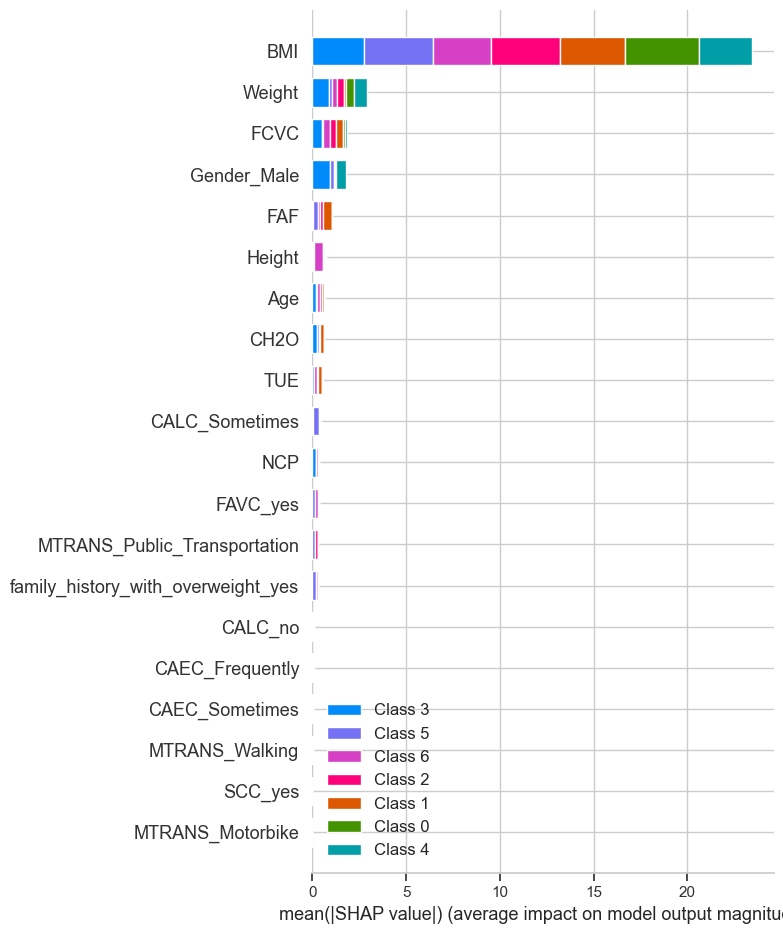

In [30]:
# SHAP summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

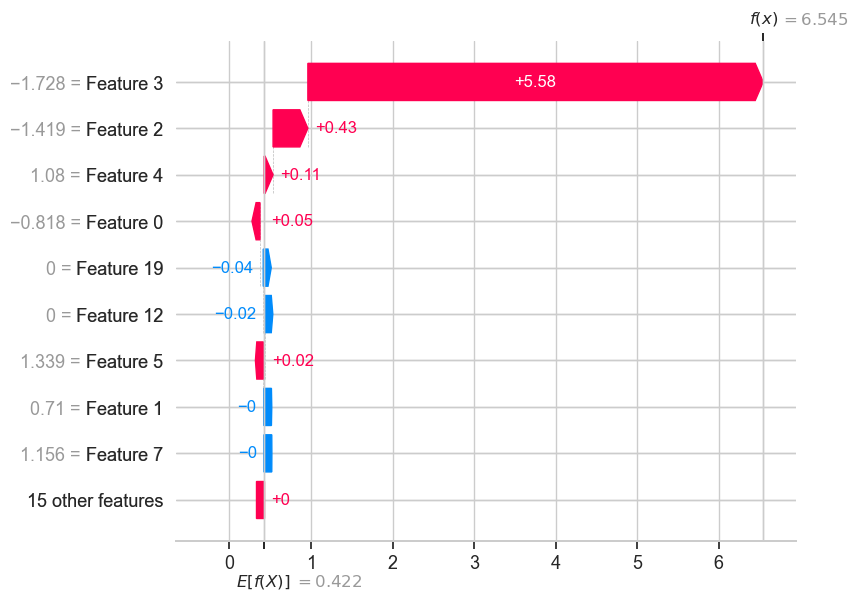

In [31]:
# Explain one prediction

pred_class = final_model.predict(X_test)[0]

shap.plots.waterfall(shap_values[0, :, pred_class])

## SHAP Explainability Insights

SHAP analysis revealed that BMI is the most influential feature in predicting obesity levels, significantly outperforming individual features such as weight and height.

This confirms that combining weight and height into BMI provides a stronger representation of body composition.

Lifestyle factors such as diet (FCVC), physical activity (FAF), and gender also contribute meaningfully to predictions, while variables like age and water intake have minimal influence.

The results demonstrate that obesity classification is driven primarily by body composition and behavioural patterns.


In [32]:
import os, joblib

os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/xgb_model.pkl")

['models/xgb_model.pkl']